In [52]:
import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

print("✅ Library successfully imported!")

✅ Library successfully imported!


In [53]:
# Reset Keras session agar nama layer selalu mulai dari 0
tf.keras.backend.clear_session()

# Build model dengan nama layer eksplisit
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3), name='block1_conv'),
    layers.MaxPooling2D((2,2), name='block1_pool'),
    layers.Conv2D(64, (3,3), activation='relu', name='block2_conv'),
    layers.MaxPooling2D((2,2), name='block2_pool'),
    layers.Conv2D(128, (3,3), activation='relu', name='block3_conv'),
    layers.MaxPooling2D((2,2), name='block3_pool'),
    layers.Flatten(name='flatten'),
    layers.Dense(128, activation='relu', name='dense'),
    layers.Dropout(0.5, name='dropout'),
    layers.Dense(1, activation='sigmoid', name='output')
])

# Build model dengan dummy input dulu
dummy = np.zeros((1, 224, 224, 3))
model(dummy)

# Load weights
model.load_weights('../glaucoma_model.keras')

print("✅ Model successfully loaded!")
print(f"Layer names:")
for i, layer in enumerate(model.layers):
    print(f"  {i}: {layer.name}")

✅ Model successfully loaded!
Layer names:
  0: block1_conv
  1: block1_pool
  2: block2_conv
  3: block2_pool
  4: block3_conv
  5: block3_pool
  6: flatten
  7: dense
  8: dropout
  9: output


In [54]:
# Load test predictions
test_df = pd.read_csv('../test_predictions.csv')
print(f"Total test data: {len(test_df)}")

# Load test images
image_folder = '../Images_augmented'
label_map = {1: 'Glaukoma', 0: 'Normal'}

X_test = []
valid_rows = []

for index, row in test_df.iterrows():
    img_path = os.path.join(image_folder, row['Image Name'])
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        img = img.resize((224, 224))
        img_array = np.array(img) / 255.0
        X_test.append(img_array)
        valid_rows.append(row)

X_test = np.array(X_test)
test_valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

print(f"Total images loaded: {len(X_test)}")
print("✅ Data is ready!")

Total test data: 217
Total images loaded: 217
✅ Data is ready!


In [55]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None):
    
    # Auto-detect last conv layer jika tidak dispesifikasi
    if last_conv_layer_name is None:
        last_conv_layer_name = [l.name for l in model.layers if isinstance(l, layers.Conv2D)][-1]
    
    # Cari split index berdasarkan nama layer
    layer_names = [l.name for l in model.layers]
    split_idx = layer_names.index(last_conv_layer_name) + 1
    
    feature_extractor = tf.keras.Sequential(model.layers[:split_idx])
    classifier = tf.keras.Sequential(model.layers[split_idx:])
    
    img_tensor = tf.cast(img_array, tf.float32)
    
    with tf.GradientTape() as tape:
        conv_outputs = feature_extractor(img_tensor)
        tape.watch(conv_outputs)
        predictions = classifier(conv_outputs)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_out = conv_outputs[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    
    return heatmap.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    overlay = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb, overlay


# Test dengan 1 gambar dulu
test_img_path = os.path.join(image_folder, test_valid_df.iloc[0]['Image Name'])
test_img = Image.open(test_img_path).convert('RGB')
test_img = test_img.resize((224, 224))
test_array = np.array(test_img) / 255.0
test_array = np.expand_dims(test_array, axis=0)

heatmap = make_gradcam_heatmap(test_array, model)
print(f"Heatmap shape: {heatmap.shape}")
print("✅ Grad-CAM successful!")

Heatmap shape: (52, 52)
✅ Grad-CAM successful!


/tmp/ipykernel_15981/4135769711.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15981/4135769711.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('../notebooks/gradcam_visualization.png', dpi=150, bbox_inches='tight')
/home/ahmad/Documents/IDSC2026/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


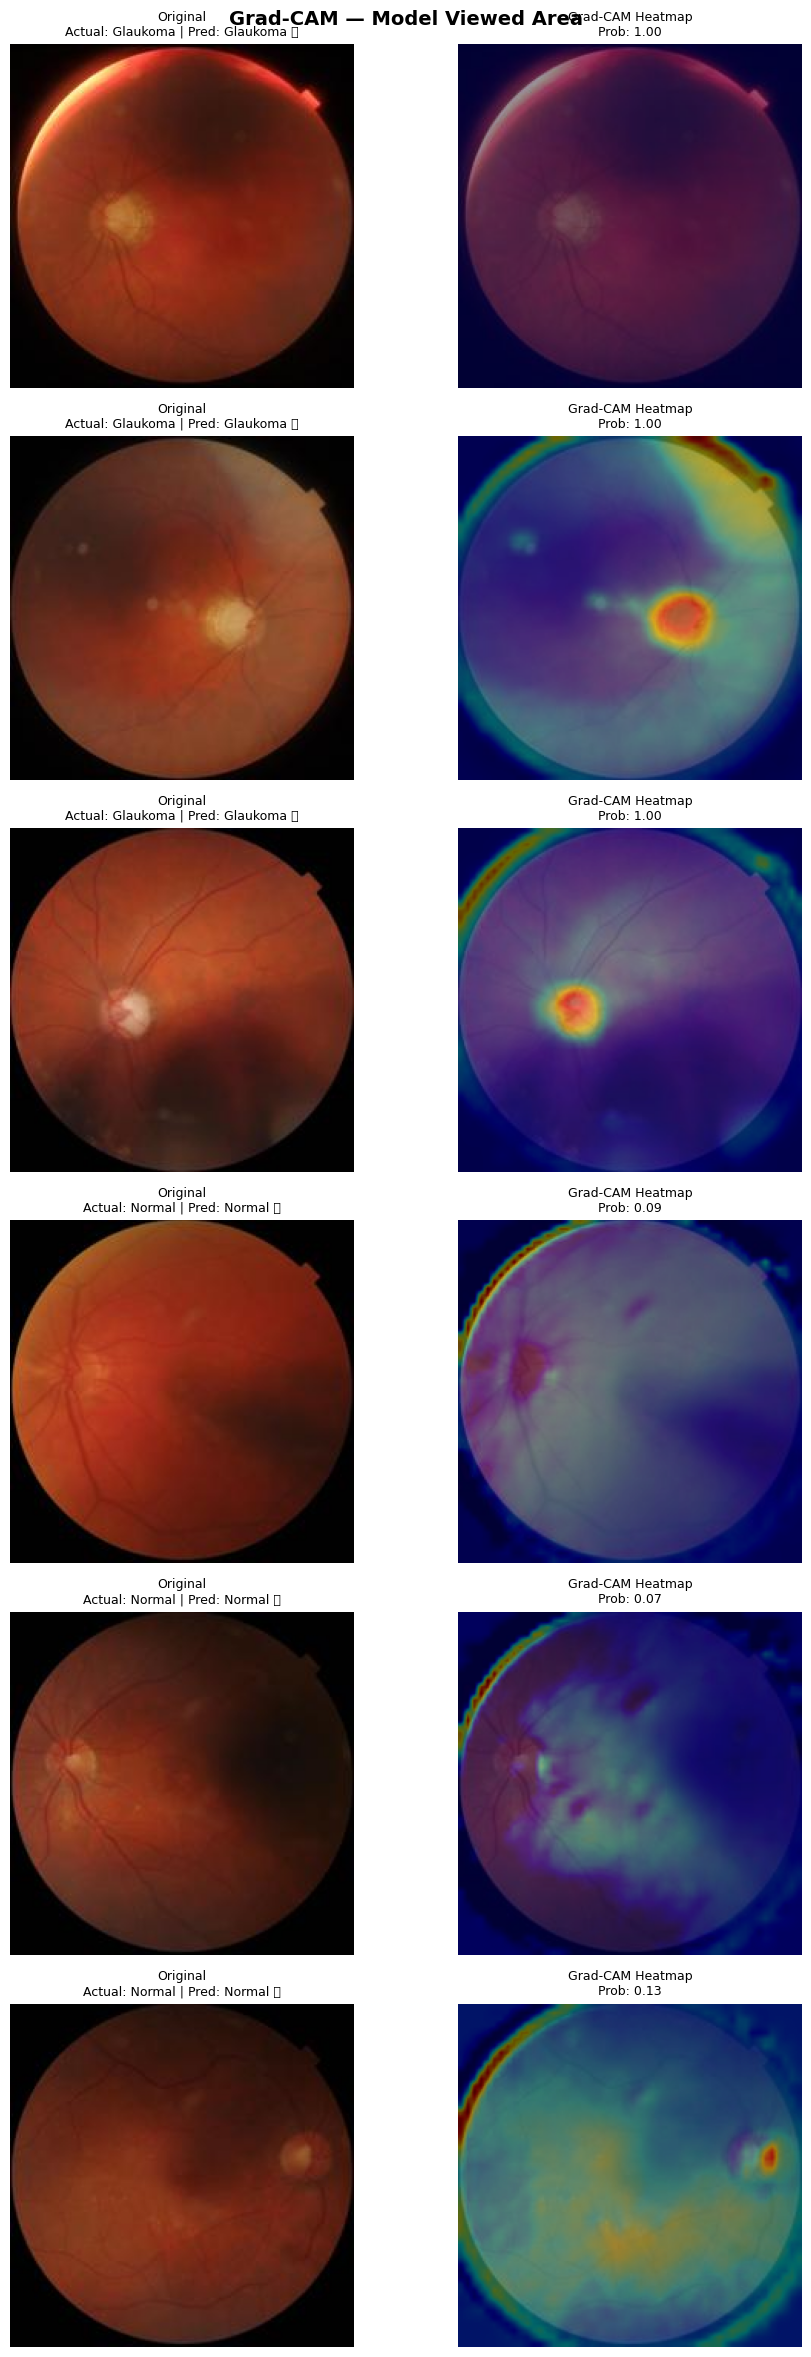

✅ Grad-CAM visualization saved!


In [56]:
# Ambil 3 GON+ dan 3 GON- sampel
gon_plus_samples = test_valid_df[
    test_valid_df['label_numeric'] == 1
].head(3)

gon_minus_samples = test_valid_df[
    test_valid_df['label_numeric'] == 0
].head(3)

samples = pd.concat([gon_plus_samples, gon_minus_samples]).reset_index(drop=True)

# Visualisasi Grad-CAM
fig, axes = plt.subplots(6, 2, figsize=(10, 24))

for i, (index, row) in enumerate(samples.iterrows()):
    img_path = os.path.join(image_folder, row['Image Name'])
    
    img = Image.open(img_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)
    
    heatmap = make_gradcam_heatmap(img_array_expanded, model)
    original, overlay = overlay_gradcam(img_path, heatmap)
    
    actual = label_map[int(row['label_numeric'])]
    predicted = label_map[int(row['prediction'])]
    prob = row['probability']
    correct = "✅" if row['correct'] else "❌"
    
    axes[i, 0].imshow(original)
    axes[i, 0].set_title(
        f"Original\nActual: {actual} | Pred: {predicted} {correct}",
        fontsize=9
    )
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(
        f"Grad-CAM Heatmap\nProb: {prob:.2f}",
        fontsize=9
    )
    axes[i, 1].axis('off')

plt.suptitle('Grad-CAM — Model Viewed Area', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grad-CAM visualization saved!")

Grad-CAM menunjukkan area mana di foto retina yang paling mempengaruhi keputusan model. Warna merah = area paling penting. Terbukti model fokus ke optic disc — area yang memang digunakan dokter untuk mendiagnosa glaukoma!